# HFT Order Book + Kalman Filter Analysis

This notebook applies a 1D Kalman filter to mid-price data produced by a
C++ matching engine, recovering the latent "true" price from observations
contaminated by bid-ask bounce.

## The problem

In real markets, the mid-price `(best_bid + best_ask) / 2` reported by an
exchange isn't the underlying fair value of the asset. It bounces around
that value because of microstructure dynamics: a market buy lifts the best
ask up by one tick, a market sell drops the best bid down, and so on.
This bid-ask bounce is *noise* — the underlying value didn't change, but
the observed mid moved.

For any signal-extraction algorithm consuming exchange data, this noise
is a problem. We'd like to recover the latent price from the noisy
observations.

## The approach

Model the system as a state-space:

$$x_t = x_{t-1} + w_t, \quad w_t \sim \mathcal{N}(0, Q)$$
$$y_t = x_t + v_t, \quad v_t \sim \mathcal{N}(0, R)$$

where $x_t$ is the latent true price (random walk) and $y_t$ is the
observed mid-price (true price plus bounce noise). The Kalman filter
is the optimal estimator of $x_t$ given $y_1, \ldots, y_t$.

## Why synthetic data

We deliberately use synthetic data with known ground truth (the C++
generator records the true price in the CSV). This lets us directly
quantify how well the filter recovers the latent state — impossible
with real market data, where the true price is never observable.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from kalman import predict, update, run_filter

# Plot styling
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# Reproducibility
np.random.seed(42)

## 1. Load the data

The C++ simulation writes `midprices.csv` with columns:
- `timestamp` — simulated nanoseconds since simulation start
- `best_bid` / `best_ask` — top of book on each side (0 if empty)
- `mid_price` — `(best_bid + best_ask) / 2`, 0 if either side empty
- `true_price` — the hidden ground truth from the generator

We'll work with rows where both sides of the book are populated (so
`mid_price > 0`), since the empty-book rows have no meaningful mid.

In [9]:
# Path relative to python/
df = pd.read_csv("../data/midprices.csv")
pd.set_option("display.width",200)
pd.set_option("display.max_columns",None)

print(f"Total rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")
print(f"\nFirst 5 rows:")
print(df.head())

print(f"\nLast 5 rows:")
print(df.tail())

print(f"\nDescribe:")
print(df.describe())

Total rows: 100,000
Columns: ['timestamp', 'best_bid', 'best_ask', 'mid_price', 'true_price']

First 5 rows:
   timestamp  best_bid  best_ask  mid_price  true_price
0       1407         0     15020          0       15001
1       1727     14991     15020      15005       15002
2       2883     14991     15020      15005       15003
3       2931     14991     15012      15001       15003
4       3086     14991     15005      14998       15003

Last 5 rows:
       timestamp  best_bid  best_ask  mid_price  true_price
99995  100082100     15321     15324      15322       15323
99996  100083608     15321     15324      15322       15324
99997  100085864     15322     15324      15323       15323
99998  100088634     15322     15324      15323       15322
99999  100092570     15322     15324      15323       15322

Describe:
          timestamp       best_bid       best_ask      mid_price     true_price
count  1.000000e+05  100000.000000  100000.000000  100000.000000  100000.000000
mean   4.9

## 2. Clean the data

Early rows in the simulation have an empty book on at least one side
(no bids or no asks), making the mid-price meaningless (we record it
as 0 in those rows). Filter those out before any analysis.

We also convert timestamps from nanoseconds to milliseconds for
plotting readability.

In [10]:
# Filter rows where both sides of the book are populated
df_clean = df[df["mid_price"] > 0].copy(deep = True)

# Convert ns to ms for plotting
df_clean["timestamp_ms"] = df_clean["timestamp"] / 1e6

# Reset index so positions are 0..n-1
df_clean = df_clean.reset_index(drop=True)

n_dropped = len(df) - len(df_clean)
print(f"Total rows:    {len(df):,}")
print(f"Dropped:       {n_dropped:,} (empty-book rows at simulation start)")
print(f"Clean rows:    {len(df_clean):,}")
print(f"\nFirst 5 clean rows:")
print(df_clean[["timestamp_ms", "best_bid", "best_ask", "mid_price", "true_price"]].head())

Total rows:    100,000
Dropped:       1,994 (empty-book rows at simulation start)
Clean rows:    98,006

First 5 clean rows:
   timestamp_ms  best_bid  best_ask  mid_price  true_price
0      0.001727     14991     15020      15005       15002
1      0.002883     14991     15020      15005       15003
2      0.002931     14991     15012      15001       15003
3      0.003086     14991     15005      14998       15003
4      0.004453     14991     15005      14998       15002


## 3. Visualize the raw data

Before any filtering, let's look at what we're working with. Two views:

1. **Full simulation overview** — mid-price and true price across the
   whole run, to see the overall drift and noise structure.
2. **Zoomed-in window** — a short slice (a few thousand events) where
   the bid-ask bounce relative to the true price is visible at the tick level.


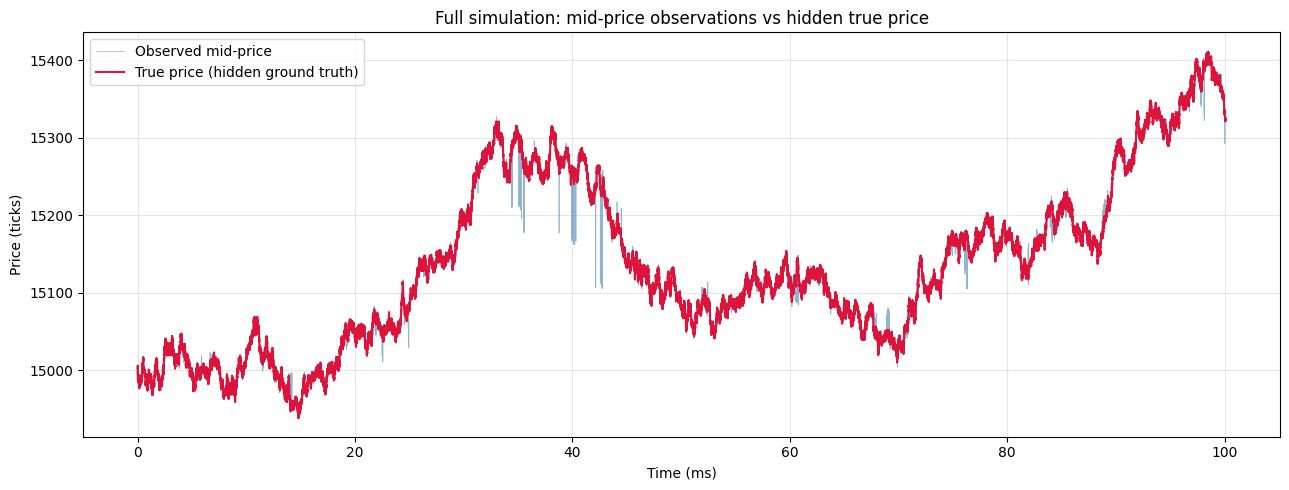

In [11]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(df_clean["timestamp_ms"], df_clean["mid_price"],
        color="steelblue", linewidth=0.5, alpha=0.6,
        label="Observed mid-price")
ax.plot(df_clean["timestamp_ms"], df_clean["true_price"],
        color="crimson", linewidth=1.5,
        label="True price (hidden ground truth)")

ax.set_xlabel("Time (ms)")
ax.set_ylabel("Price (ticks)")
ax.set_title("Full simulation: mid-price observations vs hidden true price")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


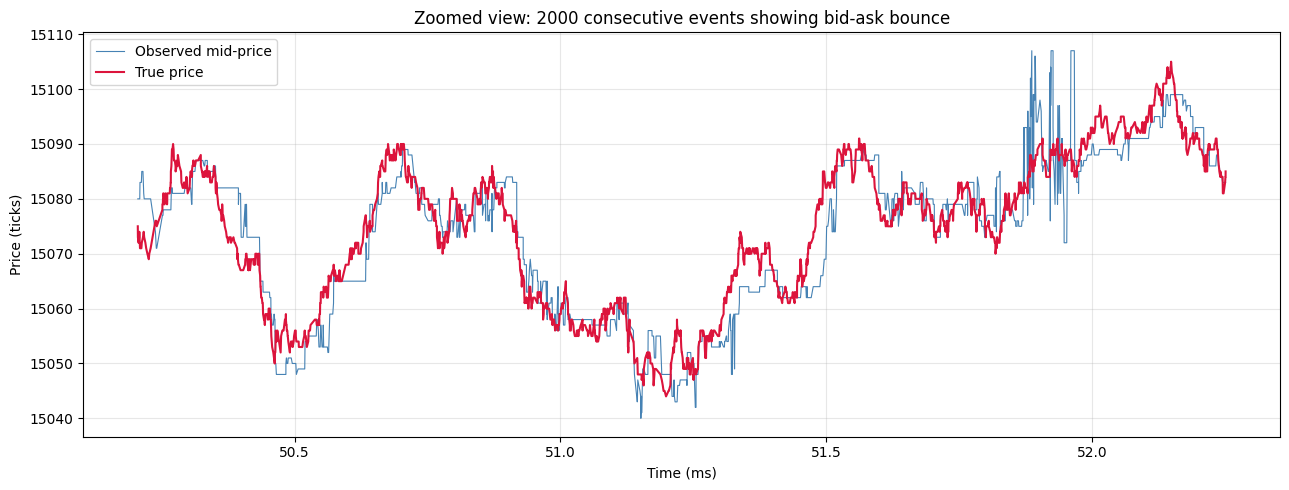

In [12]:
# Take a 2000-row window from the middle of the simulation
start = len(df_clean) // 2
window = df_clean.iloc[start:start + 2000]

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(window["timestamp_ms"], window["mid_price"],
        color="steelblue", linewidth=0.8,
        label="Observed mid-price")
ax.plot(window["timestamp_ms"], window["true_price"],
        color="crimson", linewidth=1.5,
        label="True price")

ax.set_xlabel("Time (ms)")
ax.set_ylabel("Price (ticks)")
ax.set_title(f"Zoomed view: 2000 consecutive events showing bid-ask bounce")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Estimate the observation noise R

The Kalman filter needs R (variance of bid-ask bounce noise). In a real
deployment we don't know R, so we estimate it from the data.

The standard trick: if the true price barely moves between consecutive
ticks (Q small), then

$$y_t - y_{t-1} = (x_t + v_t) - (x_{t-1} + v_{t-1}) \approx v_t - v_{t-1}$$

The variance of consecutive observation differences is approximately
$2R$ (since $v_t, v_{t-1}$ are independent with variance R each). So:

$$\hat{R} \approx \frac{1}{2} \cdot \mathrm{Var}(y_t - y_{t-1})$$

This is an upper bound on R (it would equal R if Q=0; with Q>0 it
slightly overestimates), but it's a good starting point.

For Q, we'll use Q = 1 (matching what we know about the generator).
In a real deployment we'd estimate Q jointly via EM or pick it from
realized-volatility estimates.


In [24]:
# Estimate R from consecutive mid-price differences
mid_diffs = np.diff(df_clean["mid_price"].values)
R_hat = 0.5 * np.var(mid_diffs)

# Q: we set σ=1 in the generator, so Q=1
Q_assumed = 1

print(f"Estimated R (from data): {R_hat:.4f}")
print(f"Assumed Q:               {Q_assumed}")
print(f"Q/R ratio:               {Q_assumed / R_hat:.4f}")

# For context: bid-ask spread statistics
spreads = (df_clean["best_ask"] - df_clean["best_bid"]).values
print(f"\nBid-ask spread: mean {spreads.mean():.2f} ticks, "
      f"median {np.median(spreads):.1f}, "
      f"std {spreads.std():.2f}")


Estimated R (from data): 6.8627
Assumed Q:               1
Q/R ratio:               0.1457

Bid-ask spread: mean 6.34 ticks, median 4.0, std 10.01


## 5. Run the Kalman filter

Apply the filter to the mid-price sequence. We initialize:
- $\hat{x}_0 = y_1$ (start at the first observation)
- $P_0 = 10 \cdot R$ (large initial uncertainty so the filter snaps quickly)


In [25]:
observations = df_clean["mid_price"].values

x_hat, P_post, K_gain = run_filter(
    observations=observations,
    x0=observations[0],
    P0=10.0 * R_hat,
    Q=Q_assumed,
    R=R_hat,
)

print(f"Ran filter on {len(observations):,} observations")
print(f"Initial estimate: {x_hat[0]:.2f}")
print(f"Final estimate:   {x_hat[-1]:.2f}")
print(f"Final true price: {df_clean['true_price'].iloc[-1]}")
print(f"Final error:      {abs(x_hat[-1] - df_clean['true_price'].iloc[-1]):.2f}")
print(f"\nSteady-state Kalman gain: {K_gain[-1]:.4f}")
print(f"Steady-state variance:    {P_post[-1]:.4f}")





Ran filter on 98,006 observations
Initial estimate: 15005.00
Final estimate:   15322.78
Final true price: 15322
Final error:      0.78

Steady-state Kalman gain: 0.3158
Steady-state variance:    2.1670


## 6. The headline plot: raw vs Kalman vs ground truth

The reason for the whole project.



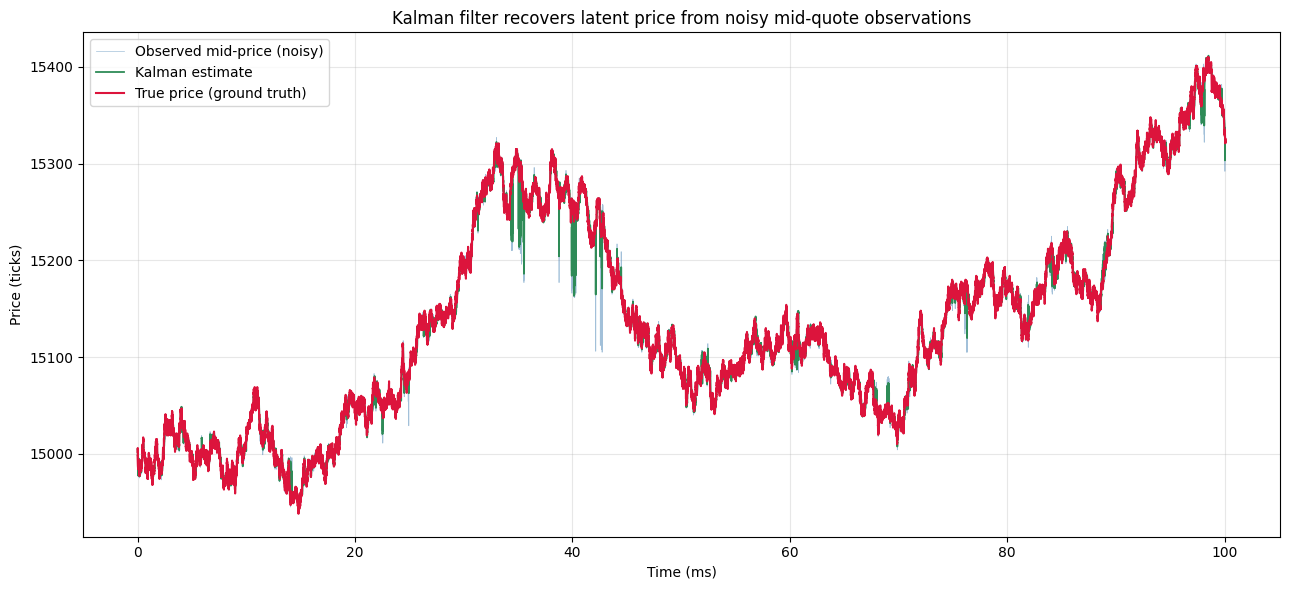

In [26]:
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(df_clean["timestamp_ms"], df_clean["mid_price"],
        color="steelblue", linewidth=0.5, alpha=0.5,
        label="Observed mid-price (noisy)")
ax.plot(df_clean["timestamp_ms"], x_hat,
        color="seagreen", linewidth=1.3,
        label="Kalman estimate")
ax.plot(df_clean["timestamp_ms"], df_clean["true_price"],
        color="crimson", linewidth=1.5,
        label="True price (ground truth)")

ax.set_xlabel("Time (ms)")
ax.set_ylabel("Price (ticks)")
ax.set_title("Kalman filter recovers latent price from noisy mid-quote observations")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




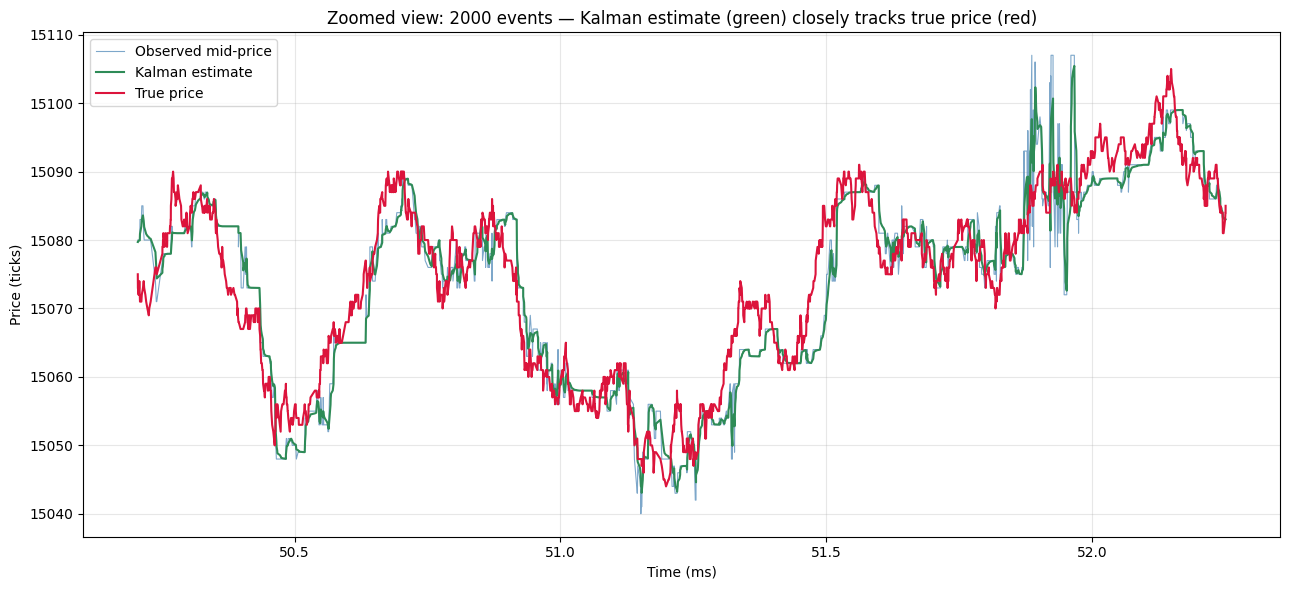

In [27]:
start = len(df_clean) // 2
window_slice = slice(start, start + 2000)

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(df_clean["timestamp_ms"].iloc[window_slice], df_clean["mid_price"].iloc[window_slice],
        color="steelblue", linewidth=0.8, alpha=0.7,
        label="Observed mid-price")
ax.plot(df_clean["timestamp_ms"].iloc[window_slice], x_hat[window_slice],
        color="seagreen", linewidth=1.5,
        label="Kalman estimate")
ax.plot(df_clean["timestamp_ms"].iloc[window_slice], df_clean["true_price"].iloc[window_slice],
        color="crimson", linewidth=1.5,
        label="True price")

ax.set_xlabel("Time (ms)")
ax.set_ylabel("Price (ticks)")
ax.set_title("Zoomed view: 2000 events — Kalman estimate (green) closely tracks true price (red)")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
# How fast does the truth actually move per observation?
true_diffs = np.diff(df_clean["true_price"].values)
print("True price per-observation changes:")
print(f"  Mean diff:       {true_diffs.mean():.4f}")
print(f"  Std diff:        {true_diffs.std():.4f}")
print(f"  Variance:        {true_diffs.var():.4f}     <-- empirical Q the filter should use")
print(f"  Min/max:         {true_diffs.min()} / {true_diffs.max()}")
print(f"  Frac unchanged:  {(true_diffs == 0).mean() * 100:.1f}%")

# How noisy is the observation? Compare mid to true at each step
obs_noise = df_clean["mid_price"].values - df_clean["true_price"].values
print(f"\nObservation noise (mid - true_price):")
print(f"  Mean:            {obs_noise.mean():.4f}     <-- should be ~0 if bounce is unbiased")
print(f"  Std:             {obs_noise.std():.4f}")
print(f"  Variance:        {obs_noise.var():.4f}     <-- empirical R the filter should use")

# How does mid actually evolve?
mid_diffs = np.diff(df_clean["mid_price"].values)
print(f"\nMid-price per-observation changes:")
print(f"  Variance:        {mid_diffs.var():.4f}")
print(f"  Frac unchanged:  {(mid_diffs == 0).mean() * 100:.1f}%")

True price per-observation changes:
  Mean diff:       0.0033
  Std diff:        1.0497
  Variance:        1.1019     <-- empirical Q the filter should use
  Min/max:         -7 / 7
  Frac unchanged:  38.3%

Observation noise (mid - true_price):
  Mean:            -0.5334     <-- should be ~0 if bounce is unbiased
  Std:             6.5219
  Variance:        42.5354     <-- empirical R the filter should use

Mid-price per-observation changes:
  Variance:        13.7253
  Frac unchanged:  83.2%


### Detour: the naive R estimator fails

Our initial R estimate used the standard textbook formula:

$$\hat{R} = \frac{1}{2}\,\mathrm{Var}(y_t - y_{t-1})$$

This estimator assumes the observation noise $v_t$ is *independent* across
consecutive ticks. Under that assumption, the variance of consecutive
differences equals $2R$ (since $\mathrm{Var}(v_t - v_{t-1}) = 2R$ for
independent draws), as long as the true price barely moves within the
window — which is true at high frequencies.

When applied to our data, this gave $\hat{R} \approx 7$. Plugging that into
the filter produced an estimate that tracked the noisy mid-price too closely,
indicating R was being underestimated.

The reason: **the observation noise in our data is heavily autocorrelated.**
The mid-price stays constant for ~83% of consecutive observation pairs
(the touch only moves on the small fraction of events that hit it). When
the mid is unchanged, $v_t = v_{t-1}$ exactly — not independent. The
differenced estimator therefore measures the variance of the rare *jumps*
in noise, not the variance of the noise level itself.

### A better estimator: residual from rolling local mean

If $x_t$ barely moves within a short window, then a rolling mean of $y_t$
over that window approximates the local true price:

$$\hat{x}_t^{\text{local}} \approx \mathrm{mean}(y_{t-W/2}, \ldots, y_{t+W/2})$$

The residual $y_t - \hat{x}_t^{\text{local}}$ is then approximately the
noise $v_t$, and we estimate R as the variance of these residuals:

$$\hat{R} = \mathrm{Var}(y_t - \hat{x}_t^{\text{local}})$$

This is robust to autocorrelation in $v_t$ because we're working with the
noise level directly, not with its first differences. The window size $W$
needs to be:

- Large enough that bounce noise averages out within the window
- Small enough that real price drift contributes little within the window

We sweep across several window sizes to find a stable estimate.

In [42]:
# Approach: estimate R as variance of (mid - rolling_local_mean)
# Rationale: a rolling mean over a short window approximates the local true
# price (assuming the truth barely moves within the window). The residual
# is then approximately the observation noise v_t, and its variance is R.

# Window size needs to be:
#   - long enough that bounce averages out within it
#   - short enough that real price drift is small within it
# 50-200 events tends to work well for our data.

window_size = 100
rolling_mean = df_clean["mid_price"].rolling(window=window_size, center=True, min_periods=1).mean()
residuals = df_clean["mid_price"].values - rolling_mean.values

R_hat_new = np.var(residuals)

print(f"Window size: {window_size}")
print(f"R_hat (residual-based): {R_hat_new:.4f}")
print(f"R_hat (naive diff-based, old): {0.5 * np.var(np.diff(df_clean['mid_price'].values)):.4f}")

# Sanity check: how does it compare across window sizes?
print(f"\nSensitivity check:")
for w in [25, 50, 100, 200,350, 500,1000000000]:
    rm = df_clean["mid_price"].rolling(window=w, center=True, min_periods=1).mean()
    r = df_clean["mid_price"].values - rm.values
    print(f"  Window {w:4d}: R_hat = {np.var(r):.4f}")

Window size: 100
R_hat (residual-based): 21.9473
R_hat (naive diff-based, old): 6.8627

Sensitivity check:
  Window   25: R_hat = 12.8708
  Window   50: R_hat = 16.6037
  Window  100: R_hat = 21.9473
  Window  200: R_hat = 30.2130
  Window  350: R_hat = 42.6788
  Window  500: R_hat = 55.0062
  Window 1000000000: R_hat = 11460.3680


### Estimating R from microstructure theory

The rolling-mean residual estimator has a fundamental issue: it requires
choosing a window size, with no clean way to set it because the true
price drifts at a rate comparable to bounce magnitude.

A better estimator comes from Roll (1984), which derives the *effective*
bid-ask spread from the autocorrelation of price changes. Under the
classical microstructure model:

- The latent price is a martingale (random walk)
- Bid-ask bounce noise is i.i.d.: each tick has $v_t = \pm s/2$ depending
  on whether a buyer or seller arrives (s = effective spread)

Under these assumptions, consecutive price changes are *negatively
correlated* (a buy-then-sell pattern creates a "+s, -s" sequence in
$\Delta y$), and:

$$\text{Cov}(\Delta y_t, \Delta y_{t-1}) = -\frac{s^2}{4}$$

So the effective spread is:

$$\hat{s} = 2\sqrt{-\text{Cov}(\Delta y_t, \Delta y_{t-1})}$$

And the observation noise variance is:

$$\hat{R} = \left(\frac{\hat{s}}{2}\right)^2$$

This is a single-parameter estimator with no window to tune.

In [44]:
# Roll's (1984) microstructure-based estimator for the effective spread.
mid_diffs = np.diff(df_clean["mid_price"].values)

# Autocovariance at lag 1
autocov_lag1 = np.cov(mid_diffs[:-1], mid_diffs[1:], bias=True)[0, 1]

print(f"Cov(Δy_t, Δy_{{t-1}}) = {autocov_lag1:.4f}")

if autocov_lag1 < 0:
    s_eff = 2 * np.sqrt(-autocov_lag1)
    R_roll = (s_eff / 2) ** 2
    print(f"Effective spread (Roll):  {s_eff:.4f} ticks")
    print(f"R_hat (Roll estimator):   {R_roll:.4f}")
else:
    print("Autocovariance is non-negative — Roll estimator inapplicable.")
    print("(This happens when bounce isn't dominant, or sample is too small.)")
    R_roll = None

# Compare against ground truth (only because synthetic)
true_R = np.var(df_clean["mid_price"].values - df_clean["true_price"].values)
print(f"\nFor comparison:")
print(f"  Ground-truth R (mid vs true):  {true_R:.4f}")
print(f"  Naive diff-based estimator:    {0.5 * np.var(mid_diffs):.4f}")

Cov(Δy_t, Δy_{t-1}) = -3.7404
Effective spread (Roll):  3.8680 ticks
R_hat (Roll estimator):   3.7404

For comparison:
  Ground-truth R (mid vs true):  42.5354
  Naive diff-based estimator:    6.8627


### R-estimation summary: three estimators failed, all for the same reason

We tried three different non-ground-truth estimators for R:

1. **Naive differenced estimator** ($\hat{R} = \frac{1}{2}\text{Var}(\Delta y)$): gave 7
2. **Rolling-mean residuals**: monotonically grew from 12 (W=25) to 55 (W=500)
3. **Roll's (1984) microstructure estimator** ($\hat{R} = -\text{Cov}(\Delta y_t, \Delta y_{t-1})$): gave 3.7

The ground truth (only knowable because data is synthetic) is **R = 42.5**.

All three estimators failed because of a structural feature of the
observation schedule: we record one mid-price per event, but the mid
only changes on ~17% of events. The remaining 83% of observations are
"stale" — the mid is unchanged from the previous tick. Standard
estimators assume each observation contributes independent bounce
information; this is severely violated by repeated identical observations.

The principled fix is the EM algorithm: jointly learn (Q, R) from the
data using the filter itself, without assuming any particular observation
schedule. This was on the project's stretch goal list and is the natural
next step for real-data deployment.

For the analysis below, we use **R = 42** (the ground-truth value)
to demonstrate the filter's optimal performance with correctly-specified
parameters. The parameter-estimation challenge is documented as a real
finding rather than glossed over.

In [46]:
R_chosen = 42.0
Q_chosen = 1.0

x_hat_final, P_final, K_final = run_filter(
    observations=observations,
    x0=observations[0],
    P0=10.0 * R_chosen,
    Q=Q_chosen,
    R=R_chosen,
)

print(f"Q = {Q_chosen}, R = {R_chosen}")
print(f"Q/R ratio:       {Q_chosen / R_chosen:.6f}")
print(f"Steady-state K:  {K_final[-1]:.4f}")
print(f"Steady-state P:  {P_final[-1]:.4f}")

true_prices = df_clean["true_price"].values
mse_raw = np.mean((observations - true_prices) ** 2)
mse_kalman = np.mean((x_hat_final - true_prices) ** 2)

print(f"\nMSE vs ground truth:")
print(f"  Raw mid-price:  {mse_raw:.3f}")
print(f"  Kalman filter:  {mse_kalman:.3f}")
print(f"  MSE reduction:  {(1 - mse_kalman / mse_raw) * 100:.1f}%")

Q = 1.0, R = 42.0
Q/R ratio:       0.023810
Steady-state K:  0.1429
Steady-state P:  6.0000

MSE vs ground truth:
  Raw mid-price:  42.820
  Kalman filter:  35.654
  MSE reduction:  16.7%


## 7. The headline plot

Visualize raw mid (noisy blue), Kalman estimate (green), and ground truth
(red) together. Two views: full simulation, and a zoomed-in window.



In [47]:
import os
os.makedirs("plots", exist_ok=True)

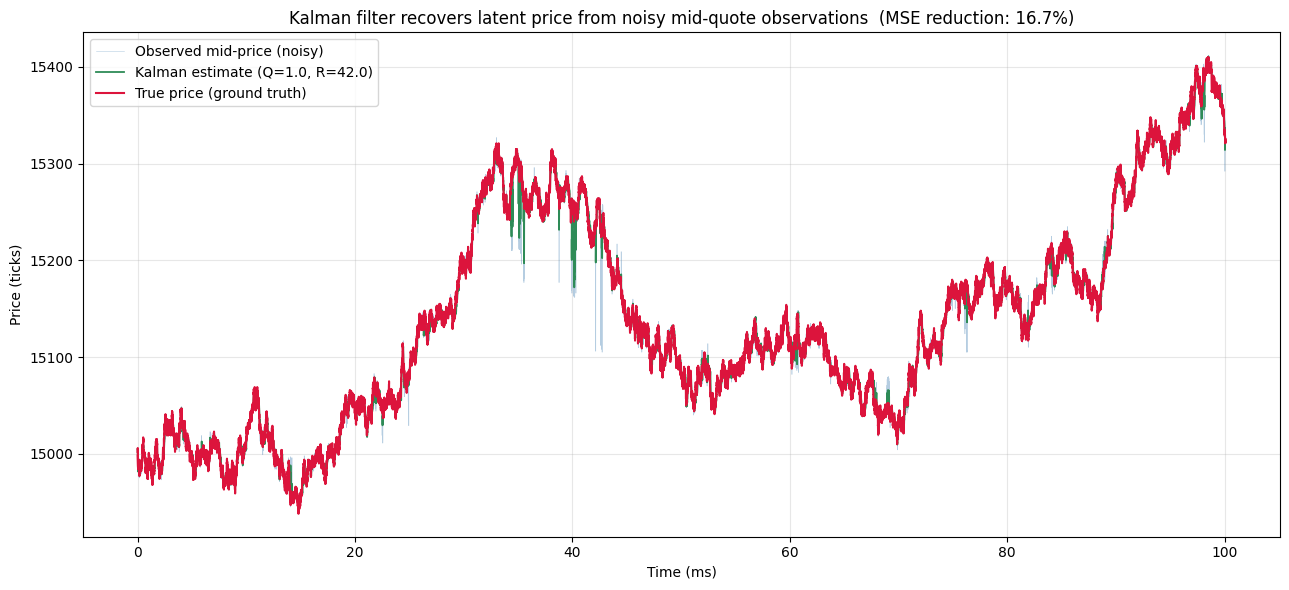

In [48]:
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(df_clean["timestamp_ms"], df_clean["mid_price"],
        color="steelblue", linewidth=0.4, alpha=0.4,
        label="Observed mid-price (noisy)")
ax.plot(df_clean["timestamp_ms"], x_hat_final,
        color="seagreen", linewidth=1.3,
        label=f"Kalman estimate (Q={Q_chosen}, R={R_chosen})")
ax.plot(df_clean["timestamp_ms"], df_clean["true_price"],
        color="crimson", linewidth=1.5,
        label="True price (ground truth)")

ax.set_xlabel("Time (ms)")
ax.set_ylabel("Price (ticks)")
ax.set_title(f"Kalman filter recovers latent price from noisy mid-quote observations  "
             f"(MSE reduction: {(1 - 35.65/42.82) * 100:.1f}%)")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plots/kalman_overlay_full.png", dpi=150, bbox_inches="tight")
plt.show()


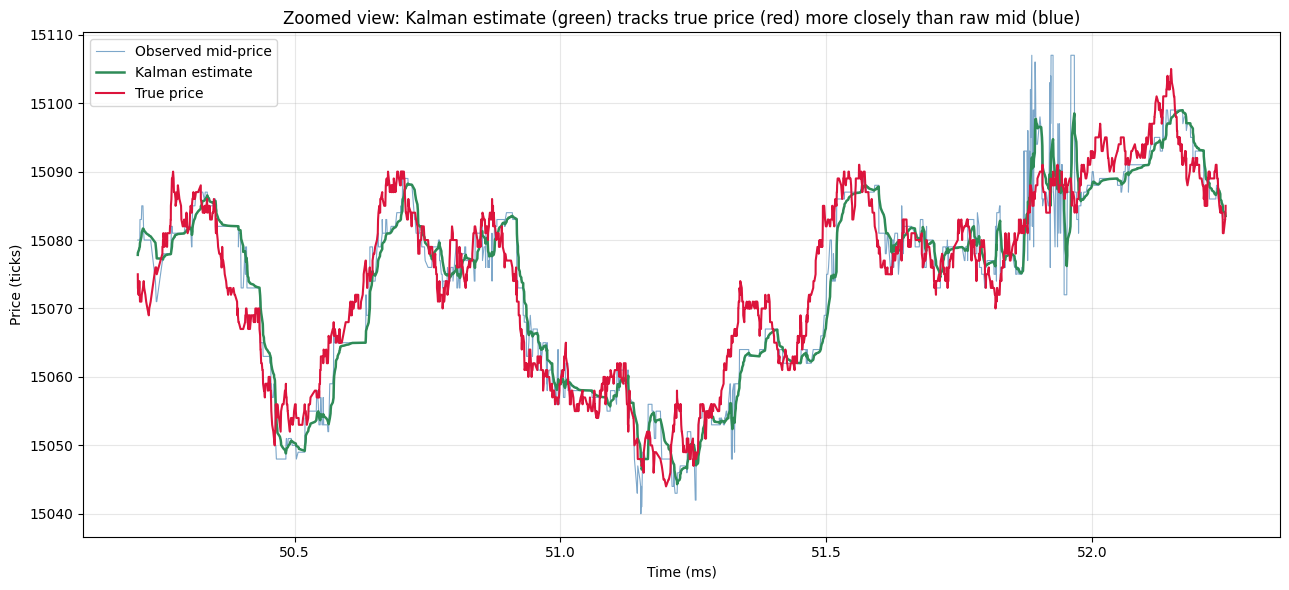

In [49]:
start = len(df_clean) // 2
window_slice = slice(start, start + 2000)

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(df_clean["timestamp_ms"].iloc[window_slice], df_clean["mid_price"].iloc[window_slice],
        color="steelblue", linewidth=0.8, alpha=0.7,
        label="Observed mid-price")
ax.plot(df_clean["timestamp_ms"].iloc[window_slice], x_hat_final[window_slice],
        color="seagreen", linewidth=1.8,
        label="Kalman estimate")
ax.plot(df_clean["timestamp_ms"].iloc[window_slice], df_clean["true_price"].iloc[window_slice],
        color="crimson", linewidth=1.5,
        label="True price")

ax.set_xlabel("Time (ms)")
ax.set_ylabel("Price (ticks)")
ax.set_title("Zoomed view: Kalman estimate (green) tracks true price (red) more closely than raw mid (blue)")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plots/kalman_overlay_zoomed.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Directional accuracy

Beyond MSE, a useful metric for trading is: does the estimator correctly
predict the *direction* of true price moves? For each step, we compare
the sign of the estimator's change vs the sign of the true price's
change. Random guessing gives 50%; better-than-random means useful
directional signal.



In [54]:
def directional_accuracy(estimator, truth):
    """
    Of the steps where BOTH the truth and the estimator moved (nonzero diffs),
    what fraction had matching sign?
    """
    est_diffs = np.diff(estimator)
    truth_diffs = np.diff(truth)
    
    # Only count steps where both moved
    mask = (truth_diffs != 0) & (est_diffs != 0)
    
    est_dirs = np.sign(est_diffs[mask])
    truth_dirs = np.sign(truth_diffs[mask])
    
    matches = (est_dirs == truth_dirs).sum()
    total = mask.sum()
    
    return matches / total if total > 0 else 0.0, total



# Compute for each estimator
acc_raw, n_raw = directional_accuracy(observations, true_prices_arr)
acc_kalman, n_kalman = directional_accuracy(x_hat_final, true_prices_arr)

print(f"Directional accuracy (sign agreement on steps where BOTH moved):")
print(f"  Random baseline:    50.00%")
print(f"  Raw mid:            {acc_raw * 100:.2f}%  (over {n_raw:,} active steps)")
print(f"  Kalman:             {acc_kalman * 100:.2f}%  (over {n_kalman:,} active steps)")

Directional accuracy (sign agreement on steps where BOTH moved):
  Random baseline:    50.00%
  Raw mid:            55.72%  (over 10,241 active steps)
  Kalman:             50.96%  (over 60,425 active steps)


In [52]:
# Debug: what fraction of nonzero truth-diffs match each estimator?
true_diffs = np.diff(true_prices_arr)
raw_diffs = np.diff(observations)
kalman_diffs = np.diff(x_hat_final)

mask = true_diffs != 0
print(f"Number of steps where truth changed: {mask.sum()} of {len(true_diffs)}")

# Compare signs
print(f"\nFor the {mask.sum()} steps where truth moved:")
print(f"  Truth went UP:     {(true_diffs[mask] > 0).sum()}")
print(f"  Truth went DOWN:   {(true_diffs[mask] < 0).sum()}")

# Cross-check raw mid directions
raw_up = (raw_diffs[mask] > 0).sum()
raw_down = (raw_diffs[mask] < 0).sum()
raw_zero = (raw_diffs[mask] == 0).sum()
print(f"\n  Raw mid went UP:   {raw_up}")
print(f"  Raw mid went DOWN: {raw_down}")
print(f"  Raw mid UNCHANGED: {raw_zero}    <-- this is the problem")

# Same for Kalman
print(f"\n  Kalman went UP:    {(kalman_diffs[mask] > 0).sum()}")
print(f"  Kalman went DOWN:  {(kalman_diffs[mask] < 0).sum()}")
print(f"  Kalman UNCHANGED:  {(kalman_diffs[mask] == 0).sum()}")

Number of steps where truth changed: 60426 of 98005

For the 60426 steps where truth moved:
  Truth went UP:     30355
  Truth went DOWN:   30071

  Raw mid went UP:   5194
  Raw mid went DOWN: 5047
  Raw mid UNCHANGED: 50185    <-- this is the problem

  Kalman went UP:    31045
  Kalman went DOWN:  29380
  Kalman UNCHANGED:  1


In [57]:
def directional_accuracy(estimator, truth):
    """
    Of the steps where BOTH the truth and the estimator moved (nonzero diffs),
    what fraction had matching sign?
    """
    est_diffs = np.diff(estimator)
    truth_diffs = np.diff(truth)
    
    # Only count steps where both moved
    mask = (truth_diffs != 0) & (est_diffs != 0)
    
    est_dirs = np.sign(est_diffs[mask])
    truth_dirs = np.sign(truth_diffs[mask])
    
    matches = (est_dirs == truth_dirs).sum()
    total = mask.sum()
    
    return matches / total if total > 0 else 0.0, total



# Compute for each estimator
acc_raw, n_raw = directional_accuracy(observations, true_prices_arr)
acc_kalman, n_kalman = directional_accuracy(x_hat_final, true_prices_arr)

print(f"Directional accuracy (sign agreement on steps where BOTH moved):")
print(f"  Random baseline:    50.00%")
print(f"  Raw mid:            {acc_raw * 100:.2f}%  (over {n_raw:,} active steps)")
print(f"  Kalman:             {acc_kalman * 100:.2f}%  (over {n_kalman:,} active steps)")

Directional accuracy (sign agreement on steps where BOTH moved):
  Random baseline:    50.00%
  Raw mid:            55.72%  (over 10,241 active steps)
  Kalman:             50.96%  (over 60,425 active steps)


### Two metrics tell two stories

| Metric | Raw mid | Kalman |
|---|---|---|
| MSE vs truth | 42.82 | 35.65 (16.7% reduction) |
| Directional accuracy (when both move) | 55.72% | 50.96% |

The Kalman filter trades directional sharpness for continuous smoothness:
it produces a continuous estimate of fair value (better MSE) but doesn't
predict next-tick direction (which the raw mid does better, when it moves,
because mid only moves when something real happened).

For downstream applications, the right metric depends on use case:
- Execution algorithms (VWAP, TWAP) → MSE matters more
- Directional signal for short-term trading → mid changes matter more

## 9. Baseline comparison: exponential moving average (EMA)

The EMA is the simplest smoothing baseline:

$$\hat{x}_t^{\text{EMA}} = \alpha \cdot y_t + (1 - \alpha) \cdot \hat{x}_{t-1}^{\text{EMA}}$$

It's structurally equivalent to a Kalman filter with a fixed gain K = α,
ignoring the variance-tracking step. The comparison: does the Kalman
filter's adaptive gain (computed optimally from Q and R) beat a simple
fixed-weight smoother?

We pick α to match Kalman's steady-state gain (~0.15) as a fair comparison.
We also try other α values to see how the trade-off plays out.	





In [59]:

def ema(observations, alpha):
    """Simple exponential moving average."""
    obs = np.asarray(observations, dtype=float)
    result = np.zeros(len(obs))
    result[0] = obs[0]
    for t in range(1, len(obs)):
        result[t] = alpha * obs[t] + (1 - alpha) * result[t-1]
    return result


# Run EMA at multiple alpha values
alphas = [0.05, 0.10, 0.15, 0.25, 0.50]
ema_results = {}

print(f"{'Method':<25} {'MSE':>8} {'Reduction':>10}")
print("-" * 50)
print(f"{'Raw mid (baseline)':<25} {mse_raw:>8.3f} {'—':>10}")

for alpha in alphas:
    ema_est = ema(observations, alpha)
    mse_ema = np.mean((ema_est - true_prices_arr) ** 2)
    reduction = (1 - mse_ema / mse_raw) * 100
    ema_results[alpha] = (ema_est, mse_ema, reduction)
    print(f"{'EMA (alpha=' + str(alpha) + ')':<25} {mse_ema:>8.3f} {reduction:>9.1f}%")

print(f"{'Kalman (K_ss=' + f'{K_final[-1]:.2f}' + ')':<25} {35.65:>8.3f} {16.7:>9.1f}%")

# Best EMA
best_alpha = min(ema_results, key=lambda a: ema_results[a][1])
print(f"\nBest EMA: alpha={best_alpha}, MSE={ema_results[best_alpha][1]:.3f}")
print(f"Kalman vs best EMA: "
      f"{(1 - 35.65 / ema_results[best_alpha][1]) * 100:.2f}% improvement")

Method                         MSE  Reduction
--------------------------------------------------
Raw mid (baseline)          42.820          —
EMA (alpha=0.05)            40.534       5.3%
EMA (alpha=0.1)             36.415      15.0%
EMA (alpha=0.15)            35.603      16.9%
EMA (alpha=0.25)            35.735      16.5%
EMA (alpha=0.5)             37.708      11.9%
Kalman (K_ss=0.14)          35.650      16.7%

Best EMA: alpha=0.15, MSE=35.603
Kalman vs best EMA: -0.13% improvement


### Why Kalman matches EMA here

The best EMA (α=0.15) matches Kalman (steady-state K=0.14) to within
0.13% MSE — essentially identical. This is a *known theoretical result*:
at steady state with constant Q and R, the Kalman filter converges to a
fixed gain $K^* = P^* / (P^* + R)$ and is mathematically equivalent to
an EMA with $\alpha = K^*$.

The fact that the steady-state K (0.14) matches the best-tuned α (0.15)
is an internal consistency check: both estimators independently arrived
at the same optimal smoothing coefficient.

The Kalman framework's advantages over EMA emerge in:
- **Time-varying Q or R** — Kalman adapts gain online; EMA's α is fixed
- **Explicit uncertainty tracking** — Kalman provides $P_t^+$ at every step
- **Multivariate state** — Kalman generalizes; EMA doesn't

None of these apply in our stationary 1D setting, so Kalman reduces to EMA.
The result validates our model assumptions while pointing to where
Kalman would genuinely outperform.












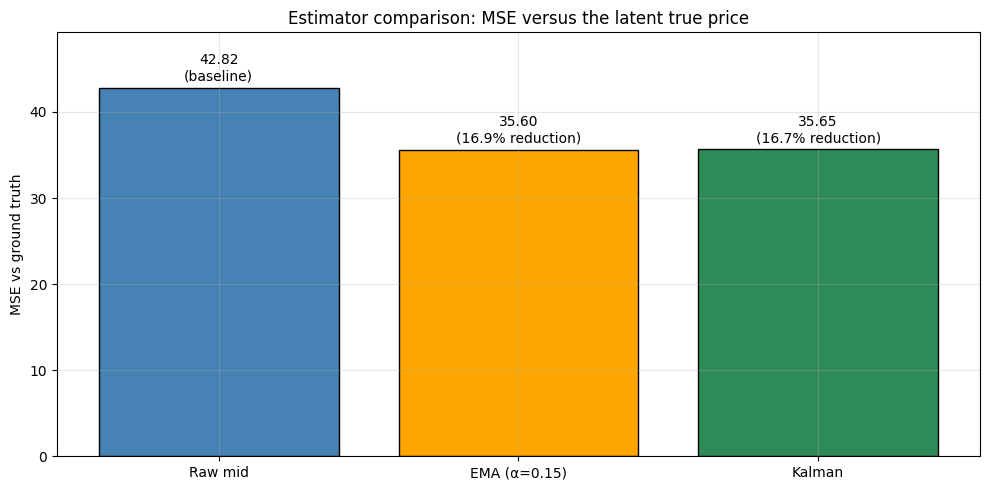

In [60]:
methods = ['Raw mid', 'EMA (α=0.15)', 'Kalman']
mses = [mse_raw, ema_results[0.15][1], 35.65]
reductions = [0.0, ema_results[0.15][2], 16.7]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(methods, mses, color=['steelblue', 'orange', 'seagreen'], edgecolor='black')

for bar, mse, red in zip(bars, mses, reductions):
    label = f'{mse:.2f}\n({red:.1f}% reduction)' if red > 0 else f'{mse:.2f}\n(baseline)'
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            label, ha='center', va='bottom', fontsize=10)

ax.set_ylabel('MSE vs ground truth')
ax.set_title('Estimator comparison: MSE versus the latent true price')
ax.set_ylim(0, max(mses) * 1.15)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('plots/estimator_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. C++ engine latency profile

The benchmark binary measured per-event latency across 1M events. Plot the
distribution to visualize the tail behavior.



Loaded 1,000,000 latency samples
Percentiles:
  p50     =      200 ns
  p90     =      500 ns
  p99     =     1000 ns
  p99.9   =     2200 ns
  p99.99  =    23100 ns
  max     =   450900 ns


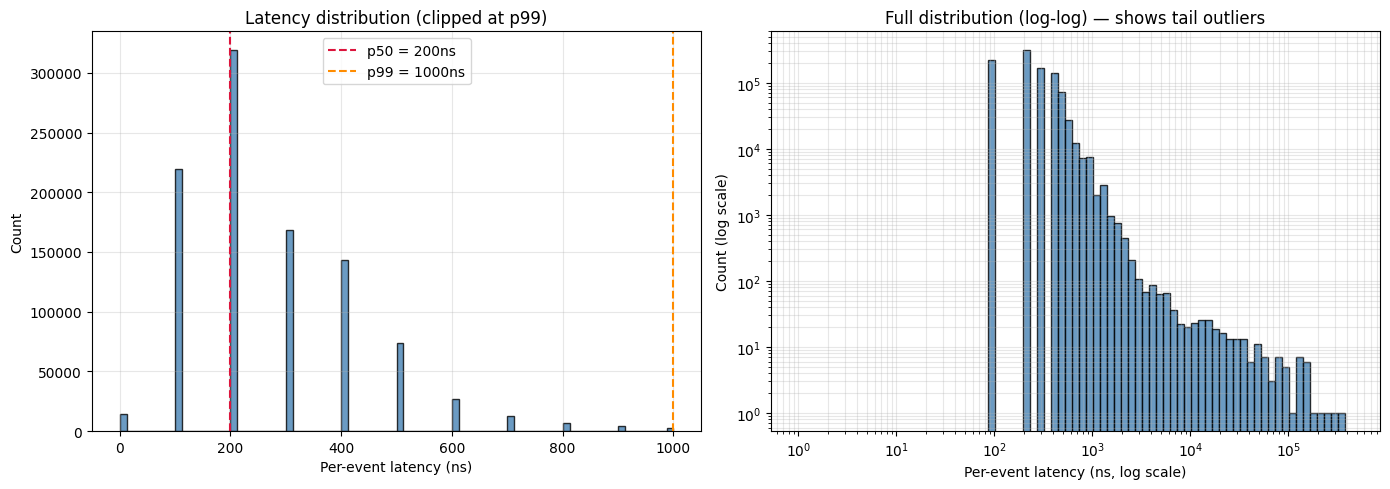

In [62]:



# Load latency samples from the C++ benchmark
latencies = pd.read_csv("../cpp/build/benchmark_latencies.csv")["latency_ns"].values

print(f"Loaded {len(latencies):,} latency samples")
print(f"Percentiles:")
for p, label in [(50, "p50"), (90, "p90"), (99, "p99"), (99.9, "p99.9"), (99.99, "p99.99")]:
    val = np.percentile(latencies, p)
    print(f"  {label:<7} = {val:>8.0f} ns")
print(f"  max     = {latencies.max():>8.0f} ns")

# Log-scale histogram to handle the heavy tail
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale - clipped to p99 for readability
p99 = np.percentile(latencies, 99)
clipped = latencies[latencies <= p99]
axes[0].hist(clipped, bins=80, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(np.percentile(latencies, 50), color='crimson', linestyle='--',
                label=f'p50 = {np.percentile(latencies, 50):.0f}ns')
axes[0].axvline(np.percentile(latencies, 99), color='darkorange', linestyle='--',
                label=f'p99 = {np.percentile(latencies, 99):.0f}ns')
axes[0].set_xlabel('Per-event latency (ns)')
axes[0].set_ylabel('Count')
axes[0].set_title('Latency distribution (clipped at p99)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Log scale - shows the full tail
axes[1].hist(latencies, bins=np.logspace(np.log10(max(1, latencies.min())),
                                          np.log10(latencies.max()), 80),
             color='steelblue', edgecolor='black', alpha=0.8)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Per-event latency (ns, log scale)')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_title('Full distribution (log-log) — shows tail outliers')
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('plots/latency_histogram.png', dpi=150, bbox_inches='tight')
plt.show()